In [ ]:
%pip install puremacro


# Tariff games: Hicksian welfare, retaliation, and numerical checks

**How do we distinguish a tariff-game candidate from a verified numerical best response?**

This hand-balanced two-country economy is synthetic. We use the same consumption expenditure function and audited accounting in every policy comparison. Country A and country B are illustrative; no actual national policy is being predicted.

## The method in math

The objective is consumption equivalent variation $EV_i=e_i(P_0,U_i)-e_i(P_0,U_{i0})$ with one fixed zero-tariff reference. EV is zero at that reference, so percentage gains divide by baseline selected consumption expenditure $m_{i0}$. Unilateral regret is $r_i=\max_t EV_i(t,\tau_{-i})-EV_i(\tau)$. A numerical Nash candidate must pass both $\max_i|BR_i(\tau_{-i})-\tau_i|\leq\epsilon_\tau$ and $\max_i r_i/m_{i0}\leq\epsilon_r$ on the declared interval.

## Intuition

**Intuition.** Small damped updates can hide a large incentive to deviate. An optimal tariff at the boundary depends on the imposed ceiling. A Prisoner's Dilemma is a property to check in the fixed-action payoff matrix; retaliation alone does not imply it. A failed general equilibrium supplies no payoff.

## Worked code

Build a balanced transaction table with one producing sector per country, two consumption baskets (categories 0 and 2), a separate investment category (1), domestic taxes and nonzero foreign balances. Fixed labor and capital payments close the production accounts.

In [1]:
from pathlib import Path
from dataclasses import replace
import sys
import numpy as np
import matplotlib.pyplot as plt

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
from puremacro.trade import (
    calibrate_trade_model, solve_policy_equilibrium,
    compute_unilateral_optimal_tariff, compute_welfare_payoff_matrix,
    solve_multilateral_nash_tariffs,
)

# Columns: intermediate A/B, then C1/I/C2 for A and C1/I/C2 for B.
flows = np.array([[10., 12., 24., 8., 6., 4., 20., 16.],
                  [8., 14., 4.5, 15., 10.5, 35., 18., 15.]])
taxes = np.array([4., 6., 1.2, 1., .8, 1.8, 2., 1.2])
value_added = flows.sum(1) - flows[:, :2].sum(0) - taxes[:2]
data = np.vstack([flows, taxes, np.r_[2*value_added/3, np.zeros(6)],
                  np.r_[value_added/3, np.zeros(6)]])
calib = calibrate_trade_model(data, ns=1, nc=2, nfd=3, country_codes=["A", "B"])
calib = replace(calib, metadata={**calib.metadata, "is_synthetic": True,
    "source": "hand-balanced teaching table", "unit": "illustrative value units"})
players = tuple(calib.country_codes)
print({k: calib.metadata[k] for k in ("source", "is_synthetic", "unit")})
assert calib.metadata["is_synthetic"]
base = solve_policy_equilibrium(calib, sigma=2., tol=1e-9)
options = dict(metric="hicksian_ev", sigma=2., consumption_categories=(0, 2),
               base_equilibrium=base, ge_tol=1e-9)

{'source': 'hand-balanced teaching table', 'is_synthetic': True, 'unit': 'illustrative value units'}


### A bounded unilateral search

Select `metric="hicksian_ev"` explicitly. The model uses CES intermediate sourcing with sigma 2, fixed Leontief final-use baskets and lump-sum fiscal rebates. The objective is conditional consumption welfare; investment is excluded. One audited baseline is shared by all searches. Percentages are EV divided by baseline consumption expenditure.

In [2]:
tariff_ceiling = 0.30
opt = compute_unilateral_optimal_tariff(calib, country_idx=players[0],
    tariff_max=tariff_ceiling, num_grid=9, method="bounded", **options)
assert opt.equilibrium.converged
assert opt.equilibrium.max_residual <= options["ge_tol"]
assert opt.baseline_welfare == 0.
print("Optimal tariff on the declared interval:", opt.optimal_tariff_rate)
print("EV / baseline consumption (%):", opt.welfare_gain_pct)
print("Boundary:", opt.metadata["boundary"])

# Fixed actions in every payoff cell: 0 or 10%, with no implicit Nash label.
payoffs = compute_welfare_payoff_matrix(calib, player_a=players[0], player_b=players[1],
    optimal_a=.10, optimal_b=.10, **options)
print(payoffs.summary())
print("Is this finite game a Prisoner's Dilemma?", payoffs.is_prisoners_dilemma)
assert all(eq.converged for eq in payoffs.scenarios.values())

Optimal tariff on the declared interval: 0.3
EV / baseline consumption (%): 7.145081703233689
Boundary: upper
                       B: 0%                B: 10%
A: 0%   (+0.0000%, +0.0000%)  (-3.5645%, +4.5201%)
A: 10%  (+2.6308%, -2.1820%)  (-1.0039%, +2.4065%)
Is this finite game a Prisoner's Dilemma? False


### Numerical best-response diagnostics

Each equilibrium attempt is audited. Automatic recovery tries Newton, hybrid and then Keller continuation without relaxing the tolerance; exhausted recovery raises an error. Convergence requires simultaneous best responses at the final policy vector and consumption-normalized regret. The result can be inconclusive; report that outcome without asserting a Nash theorem.

In [3]:
nash = solve_multilateral_nash_tariffs(calib, player_countries=players,
    tariff_max=tariff_ceiling, best_response_grid_size=7, max_iter=20,
    relaxation=.8, tol=1e-4, regret_tol=1e-6, **options)
print("Candidate tariffs:", nash.nash_tariffs)
print("Numerical convergence:", nash.converged)
print("Final simultaneous best-response gap:", nash.outer_error)
print("Maximum regret / baseline consumption:", nash.metadata["relative_max_regret"])
print("Boundary status:", nash.metadata["best_response_boundaries"])
print("Final GE attempts:", nash.equilibrium.metadata["policy_solver_attempts"])
if nash.converged:
    assert nash.equilibrium.converged and nash.outer_error <= 1e-4
    assert nash.metadata["relative_max_regret"] <= 1e-6
    assert not nash.metadata["inner_solver_failures"]

Candidate tariffs: {'A': 0.29999923199999995, 'B': 0.29999923199999995}
Numerical convergence: True
Final simultaneous best-response gap: 7.680000000398479e-07
Maximum regret / baseline consumption: 2.56241740872982e-07
Boundary status: {'A': 'upper', 'B': 'upper'}
Final GE attempts: [{'method': 'newton', 'seed': 'warm', 'requested_tolerance': 1e-09, 'accepted': True, 'solver_converged': True, 'solver_max_residual': 6.045297595846932e-11, 'audited_max_residual': 1.5660361896152608e-10, 'warnings': []}]


[Text(0.0, 1.0, 'Undamped iteration gaps'),
 Text(0.5, 0, 'Iteration'),
 Text(0, 0.5, 'Policy gap')]

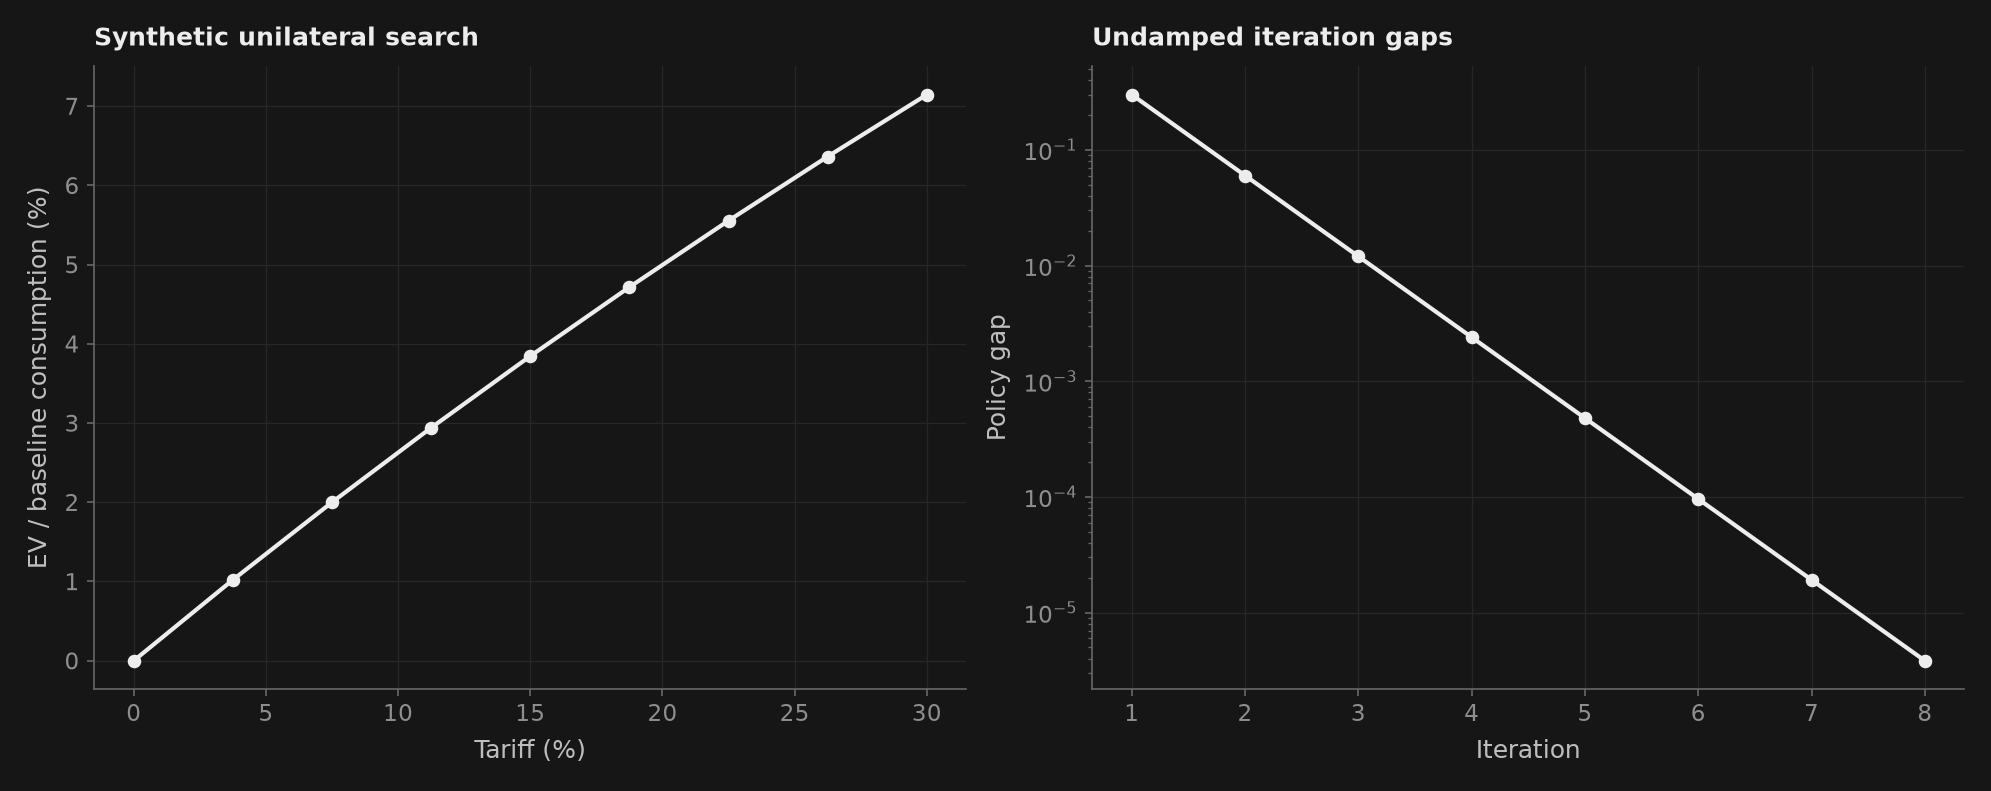

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
gain = 100 * opt.welfare_curve / opt.metadata["baseline_consumption_by_country"][0]
axes[0].plot(100 * opt.tariff_grid, gain, marker="o", color=_nbstyle.TINTA)
axes[0].set(title="Synthetic unilateral search", xlabel="Tariff (%)",
            ylabel="EV / baseline consumption (%)")
iterations = [h["iteration"] for h in nash.iteration_history]
gaps = [h["undamped_update_gap"] for h in nash.iteration_history]
axes[1].semilogy(iterations, np.maximum(gaps, 1e-16), marker="o", color=_nbstyle.TINTA)
axes[1].set(title="Undamped iteration gaps", xlabel="Iteration", ylabel="Policy gap")

## Read the output

The monetary welfare curve has a zero baseline. Its percentage display uses fixed baseline consumption, not division by baseline EV. Every payoff cell uses the same two actions per player. The convergence flag concerns the declared numerical search: inspect its ceiling, boundary status, grid resolution and final regret. The benchmark does not establish unique or interior optimal tariffs.

## Your turn

Change the ceiling and compare the candidate and diagnostics. An upper-bound response can move with the institutional constraint.

In [5]:
custom_ceiling = 0.20  # ← change this
assert 0 < custom_ceiling <= .50
custom = solve_multilateral_nash_tariffs(calib, player_countries=players,
    tariff_max=custom_ceiling, best_response_grid_size=7, max_iter=20,
    relaxation=.8, tol=1e-4, regret_tol=1e-6, **options)
assert all(0 <= t <= custom_ceiling for t in custom.nash_tariffs.values())
print("Alternative candidate:", custom.nash_tariffs)
print("Converged / gap / relative regret:", custom.converged, custom.outer_error,
      custom.metadata["relative_max_regret"])

Alternative candidate: {'A': 0.19999744000000003, 'B': 0.19999744000000003}
Converged / gap / relative regret: True 2.5599999999847967e-06 9.583755619847738e-07


## How comprehensive is this?

This is a reproducible teaching exercise, not an empirical trade-war forecast. A separately derived scalar CES equilibrium and primal expenditure minimization validate a complete 41-by-41 tariff grid; see `reviews/2026-09-20-hicksian-policy/REPORT.md`. Grid and local searches can still miss narrow peaks. Hicksian EV is available for the declared consumption preferences and consistent accounting; causal TOT/Alloc/TariffRec decomposition and theorem certification remain unavailable. See `docs/trade_policy.md`.